In [4]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/image-to-black-white/src")

In [5]:
import os
from PIL import Image


# Sciezki folderow
folder_zrodlowy = "../data"
folder_docelowy = "../out"


# Tworzenie folderu docelowego, jesli nie istnieje
if not os.path.exists(folder_docelowy):
    os.makedirs(folder_docelowy)


# Lista rozszerzen plikow do konwersji
rozszerzenia = [".jpg", ".jpeg", ".png"]


# Petla po plikach w folderze zrodlowym
for nazwa_pliku in os.listdir(folder_zrodlowy):
    # Sprawdzanie, czy plik ma odpowiednie rozszerzenie
    
    sciezka_zrodlowa = ""
    
    if any(nazwa_pliku.lower().endswith(ext) for ext in rozszerzenia):
        # Tworzenie pelnej sciezki do pliku zrodlowego
        sciezka_zrodlowa = os.path.join(folder_zrodlowy, nazwa_pliku)


    try:
        # Otwieranie obrazu
        obraz = Image.open(sciezka_zrodlowa)


        # Tworzenie nazwy pliku docelowego
        nazwa_pliku_docelowego = os.path.splitext(nazwa_pliku)[0] + ".jpg"
        sciezka_docelowa = os.path.join(
        folder_docelowy, nazwa_pliku_docelowego
        )


        # Konwersja i zapisywanie obrazu
        obraz = obraz.convert("RGB")  # Konwersja do trybu RGB
        obraz.save(sciezka_docelowa, "JPEG")


        print(f"Skonwertowano i zapisano: {nazwa_pliku} -> {nazwa_pliku_docelowego}")
    except Exception as e:
        print(f"Blad podczas konwersji {nazwa_pliku}: {e}")


print("Konwersja zakonczona.")

Blad podczas konwersji .ipynb_checkpoints: 'str' object has no attribute 'read'
Skonwertowano i zapisano: image1.jpeg -> image1.jpg
Skonwertowano i zapisano: image2.jpg -> image2.jpg
Skonwertowano i zapisano: image3.jpg -> image3.jpg
Skonwertowano i zapisano: image4.png -> image4.jpg
Skonwertowano i zapisano: image5.jpg -> image5.jpg
Konwersja zakonczona.


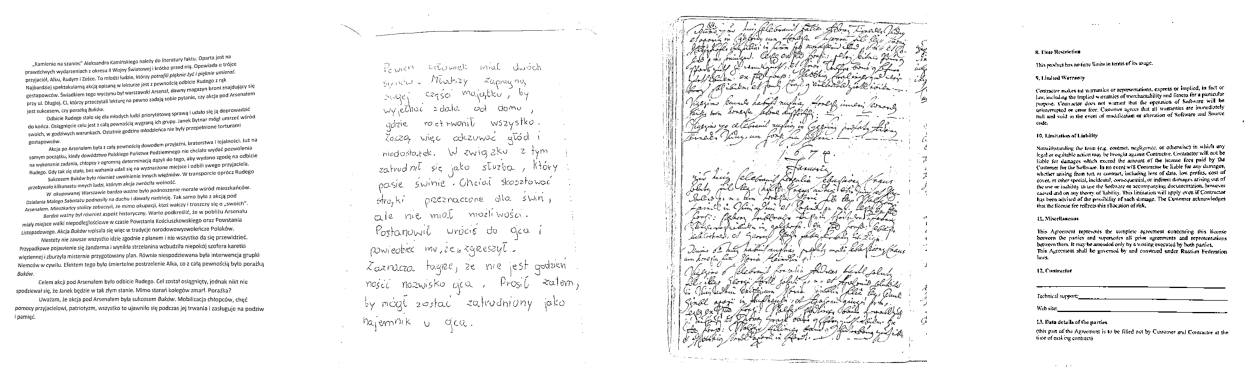

In [28]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

nazwy_plikow = [
    # "../out/image1.jpg",
    "../out/image2.jpg",
    "../out/image3.jpg",
    "../out/image4.jpg",
    "../out/image5.jpg"
]

kernel1 = np.array([[-1,  -1, -1],
                   [-1,  8,  -1],
                   [-1, -1,  -1]])

kernel2 = np.array([[1,  0, -1], 
                    [0,  0,  0], 
                    [-1, 0,  1]])

kernel3 = np.array([[1, 4, 6, 4, 1],
                    [4, 16, 24, 16, 4],
                    [6, 24, 36, 24, 6],
                    [4, 16, 24, 16, 4],
                    [1, 4, 6, 4, 1]]) / 256

kernel4 = np.array([[0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]])

columns = 4
rows = 1

fig = plt.figure(figsize=(16, 8))

new_images = []

index = 1
for nazwa_pliku in nazwy_plikow:
    if not os.path.exists(nazwa_pliku):
        print("plik", nazwa_pliku, "nie istnieje")
        continue
        
    img = cv2.imread(nazwa_pliku)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 17, 30)
    
    # img = cv2.filter2D(img, -1, kernel4)
    
    new_images.append(img)
    
    fig.add_subplot(rows, columns, index)
    plt.axis('off')
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    
    index += 1

plt.show()

# plt.imshow(img, cmap=plt.get_cmap('gray'))

In [29]:
for i, x in enumerate(new_images):
    print(f"saving {i}th image")
    cv2.imwrite(f"../out2/image{i}.jpg", x)

saving 0th image
saving 1th image
saving 2th image
saving 3th image
